# Polygon Distribution Comparison

Use this notebook to compare training polygons against generated polygons for both fixed-size and variable-size datasets.

The notebook now separates analyses into two groups:
- dataset-wide analyses that work on every polygon regardless of vertex count
- size-conditioned analyses that only run on a shared `n_vertices` subset when a flattened same-width representation is required

The workflow still canonicalizes translation, scale, orientation, and cyclic vertex offset so that the comparison emphasizes shape differences rather than arbitrary pose.


In [23]:
import importlib
import sys
from pathlib import Path


def ensure_repo_on_path() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "pyproject.toml").exists() and (root / "polydiff").is_dir():
            root_str = str(root)
            if root_str not in sys.path:
                sys.path.insert(0, root_str)
            return root
    raise RuntimeError(
        "Could not locate repo root. Start Jupyter from this repo or install with: pip install -e .[dev]"
    )


REPO_ROOT = ensure_repo_on_path()

mod = sys.modules.get("polydiff")
if mod is not None:
    mod_file = Path(getattr(mod, "__file__", "") or "")
    if not mod_file.exists() or REPO_ROOT not in mod_file.parents:
        del sys.modules["polydiff"]

polydiff = importlib.import_module("polydiff")
print(f"repo root: {REPO_ROOT}")
print(f"polydiff module: {getattr(polydiff, '__file__', 'unknown')}")


repo root: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff
polydiff module: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/polydiff/__init__.py


In [24]:
import math
import re

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from polydiff import paths
from polydiff.data.gen_polygons import (
    centroid_xy,
    edge_lengths,
    enforce_ccw,
    is_self_intersecting,
    normalize_scale_rms,
    polygon_signed_area_xy,
    regularity_score,
)
from polydiff.data.plot_polygons import plot_polygon
from polydiff.data.polygon_dataset import load_polygon_dataset as load_polygon_file
from polydiff.runs import is_run_dir_name, is_sample_run_dir_name, latest_model_run_dir, latest_sampling_run_dir

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:,.4f}".format


In [25]:
def list_npz_files(folder: Path) -> list[Path]:
    return sorted(folder.rglob("*.npz"))


def preferred_or_first(files: list[Path], preferred_name: str, fallback_dir: Path) -> Path:
    preferred = sorted([p for p in files if p.name == preferred_name])
    if preferred:
        return preferred[-1]
    if files:
        return files[-1]
    return fallback_dir / preferred_name


def default_generated_path(processed_files: list[Path]) -> Path:
    try:
        latest_run_dir = latest_model_run_dir()
    except FileNotFoundError:
        latest_run_dir = None

    if latest_run_dir is not None:
        try:
            latest_sample_dir = latest_sampling_run_dir(latest_run_dir.name)
        except FileNotFoundError:
            latest_sample_dir = None
        if latest_sample_dir is not None:
            candidate = latest_sample_dir / "samples.npz"
            if candidate.exists():
                return candidate

        candidate = paths.PROCESSED_DATA_DIR / latest_run_dir.name / "samples.npz"
        if candidate.exists():
            return candidate

    return preferred_or_first(processed_files, "samples.npz", paths.PROCESSED_DATA_DIR)


def default_figure_save_dir(generated_path: Path) -> Path:
    parent = generated_path.parent
    if is_sample_run_dir_name(parent.name):
        return parent / "media" / "notebooks" / "compare_polygon_distributions"
    if is_run_dir_name(parent.name):
        return parent / "media" / "notebooks" / "compare_polygon_distributions"
    return paths.PROCESSED_DATA_DIR / "media" / "notebooks" / "compare_polygon_distributions"


raw_files = list_npz_files(paths.RAW_DATA_DIR)
processed_files = list_npz_files(paths.PROCESSED_DATA_DIR)

print("Available raw datasets:")
for p in raw_files:
    print(f"  - {p.relative_to(REPO_ROOT)}")

print()
print("Available processed datasets:")
for p in processed_files:
    print(f"  - {p.relative_to(REPO_ROOT)}")

TRAIN_PATH = preferred_or_first(raw_files, "hexagons_noisy.npz", paths.RAW_DATA_DIR)
GENERATED_PATH = default_generated_path(processed_files)
SELECTED_SAMPLE_RUN_NAME = GENERATED_PATH.parent.name if is_sample_run_dir_name(GENERATED_PATH.parent.name) else None
if SELECTED_SAMPLE_RUN_NAME is not None and GENERATED_PATH.parent.parent.name and is_run_dir_name(GENERATED_PATH.parent.parent.name):
    SELECTED_RUN_NAME = GENERATED_PATH.parent.parent.name
elif is_run_dir_name(GENERATED_PATH.parent.name):
    SELECTED_RUN_NAME = GENERATED_PATH.parent.name
else:
    SELECTED_RUN_NAME = None

MAX_GALLERY = 16
MAX_PCA_SAMPLES_PER_SET = 5000
RANDOM_SEED = 0
AUTO_SAVE_FIGURES = True
ANALYSIS_N_VERTICES = None  # Set to an int to force PCA/vertex-density analysis on that polygon size.
FIGURE_SAVE_DIR = default_figure_save_dir(GENERATED_PATH)
if AUTO_SAVE_FIGURES:
    paths.ensure_dir(FIGURE_SAVE_DIR)

print()
print(f"Selected training file: {TRAIN_PATH.relative_to(REPO_ROOT) if TRAIN_PATH.exists() else TRAIN_PATH}")
print(f"Selected generated file: {GENERATED_PATH.relative_to(REPO_ROOT) if GENERATED_PATH.exists() else GENERATED_PATH}")
print(f"Selected model run: {SELECTED_RUN_NAME or '<none>'}")
print(f"Selected sample run: {SELECTED_SAMPLE_RUN_NAME or '<none>'}")
print(f"Figure save dir: {FIGURE_SAVE_DIR.relative_to(REPO_ROOT)}")

if not TRAIN_PATH.exists() or not GENERATED_PATH.exists():
    raise FileNotFoundError(
        "Update TRAIN_PATH and GENERATED_PATH in this cell to existing .npz files before running the notebook."
    )


Available raw datasets:
  - data/raw/hexagons.npz
  - data/raw/hexagons_10k.npz
  - data/raw/hexagons_noisy.npz
  - data/raw/loud_hex.npz
  - data/raw/mixed_polygons.npz
  - data/raw/pentagons.npz

Available processed datasets:
  - data/processed/old/samples/sample_reg.npz
  - data/processed/old/samples/samples.npz
  - data/processed/old/samples.npz
  - data/processed/run_0001__polydiff-train-gat-hexagons-noisy/sample_0001__polydiff-sample-unguided/samples.npz
  - data/processed/run_0001__polydiff-train-gat-hexagons-noisy/sample_0002__polydiff-sample-regularity-guided/samples.npz
  - data/processed/run_0001__polydiff-train-gat-hexagons-noisy/sample_0003__polydiff-sample-regularity-guided/samples.npz
  - data/processed/run_0001__polydiff-train-gat-hexagons-noisy/sample_0004__polydiff-sample-regularity-guided/samples.npz
  - data/processed/run_0002__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/samples.npz
  - data/processed/run_0003__polydiff-train-gat-mixed-po

In [26]:
def coerce_meta(data) -> object:
    if "meta" not in data:
        return {}
    meta_value = data["meta"]
    if getattr(meta_value, "shape", ()) == ():
        return meta_value.item()
    return meta_value.tolist()


def format_size_histogram(hist: dict[int, int]) -> str:
    return ", ".join(f"{int(k)}:{int(v)}" for k, v in sorted(hist.items())) or "<empty>"


def load_polygon_dataset(file_path: Path, label: str) -> dict[str, object]:
    polygon_data = load_polygon_file(file_path)
    with np.load(file_path, allow_pickle=True) as data:
        polygons = [polygon_data.polygon(i).astype(np.float32, copy=False) for i in range(polygon_data.num_polygons)]
        num_vertices = np.asarray(polygon_data.num_vertices, dtype=np.int32)
        score = np.asarray(data["score"], dtype=np.float32) if "score" in data else None
        deform = np.asarray(data["deform"], dtype=np.float32) if "deform" in data else None
        meta = coerce_meta(data)

    if score is not None and len(score) != len(polygons):
        raise ValueError(f"{file_path} score length {len(score)} does not match polygon count {len(polygons)}")
    if deform is not None and len(deform) != len(polygons):
        raise ValueError(f"{file_path} deform length {len(deform)} does not match polygon count {len(polygons)}")

    unique, counts = np.unique(num_vertices, return_counts=True)
    size_histogram = {int(k): int(v) for k, v in zip(unique.tolist(), counts.tolist())}
    n_vertices = int(num_vertices[0]) if len(num_vertices) > 0 and np.all(num_vertices == num_vertices[0]) else None

    return {
        "label": label,
        "path": file_path,
        "polygons": polygons,
        "num_vertices": num_vertices,
        "n_vertices": n_vertices,
        "is_uniform": n_vertices is not None,
        "size_histogram": size_histogram,
        "score": score,
        "deform": deform,
        "meta": meta,
    }


def anchor_index(xy: np.ndarray) -> int:
    return int(np.lexsort((xy[:, 1], -xy[:, 0]))[0])


def canonicalize_polygon(xy: np.ndarray) -> np.ndarray:
    xy = np.asarray(xy, dtype=np.float64)
    xy = xy - centroid_xy(xy)
    xy = normalize_scale_rms(xy)
    xy = enforce_ccw(xy)

    start = anchor_index(xy)
    xy = np.roll(xy, -start, axis=0)

    theta = math.atan2(float(xy[0, 1]), float(xy[0, 0]))
    c = math.cos(-theta)
    s = math.sin(-theta)
    rotation = np.array([[c, -s], [s, c]], dtype=np.float64)
    xy = xy @ rotation.T
    return xy.astype(np.float32)


def polygon_metric_row(xy: np.ndarray) -> tuple[dict[str, float], np.ndarray]:
    xy = canonicalize_polygon(xy)
    reg = regularity_score(xy.astype(np.float64))
    lengths = edge_lengths(xy).astype(np.float64)
    radii = np.linalg.norm(xy, axis=1).astype(np.float64)

    area = abs(polygon_signed_area_xy(xy))
    perimeter = float(lengths.sum())
    compactness = float(4.0 * math.pi * area / (perimeter ** 2 + 1e-12))
    width = float(xy[:, 0].max() - xy[:, 0].min())
    height = float(xy[:, 1].max() - xy[:, 1].min())

    row = {
        "score": float(reg.score),
        "edge_cv": float(reg.edge_cv),
        "angle_cv": float(reg.angle_cv),
        "radius_cv": float(reg.radius_cv),
        "area": float(area),
        "perimeter": perimeter,
        "compactness": compactness,
        "width": width,
        "height": height,
        "bbox_aspect": float(width / (height + 1e-12)),
        "min_radius": float(radii.min()),
        "max_radius": float(radii.max()),
        "min_edge": float(lengths.min()),
        "max_edge": float(lengths.max()),
        "self_intersecting": float(is_self_intersecting(xy)),
    }
    return row, xy


def build_metrics_frame(dataset: dict[str, object]) -> tuple[pd.DataFrame, list[np.ndarray]]:
    polygons = list(dataset["polygons"])
    num_vertices = np.asarray(dataset["num_vertices"], dtype=np.int32)
    score = dataset["score"]
    deform = dataset["deform"]

    aligned: list[np.ndarray] = []
    rows: list[dict[str, float | int | str]] = []
    for i, xy in enumerate(polygons):
        row, xy_aligned = polygon_metric_row(xy)
        row["dataset"] = str(dataset["label"])
        row["index"] = i
        row["n_vertices"] = int(num_vertices[i])
        if score is not None:
            row["stored_score"] = float(score[i])
            row["score_error"] = row["score"] - row["stored_score"]
        if deform is not None:
            row["deform"] = float(deform[i])
        rows.append(row)
        aligned.append(xy_aligned)

    return pd.DataFrame(rows), aligned


def choose_indices(n: int, count: int, seed: int) -> np.ndarray:
    if n <= count:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=count, replace=False))


def sample_items(items, max_items: int, seed: int):
    idx = choose_indices(len(items), max_items, seed)
    return [items[i] for i in idx], idx


def sample_rows(x: np.ndarray, max_rows: int, seed: int) -> np.ndarray:
    idx = choose_indices(len(x), max_rows, seed)
    return x[idx]


def fit_pca_2d(arrays: dict[str, np.ndarray], max_samples_per_set: int, seed: int) -> tuple[dict[str, np.ndarray], np.ndarray]:
    sampled: dict[str, np.ndarray] = {}
    chunks: list[np.ndarray] = []
    start_seed = seed
    for label, arr in arrays.items():
        flat = arr.reshape(len(arr), -1)
        subset = sample_rows(flat, max_samples_per_set, start_seed)
        sampled[label] = subset
        chunks.append(subset)
        start_seed += 1

    X = np.vstack(chunks)
    X = X - X.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(X, full_matrices=False)
    components = vt[:2]
    embedded = X @ components.T
    explained = (singular_values[:2] ** 2) / np.sum(singular_values ** 2)

    out: dict[str, np.ndarray] = {}
    offset = 0
    for label, subset in sampled.items():
        next_offset = offset + len(subset)
        out[label] = embedded[offset:next_offset]
        offset = next_offset
    return out, explained


def figure_slug(stem: str) -> str:
    slug = re.sub(r"[^a-zA-Z0-9]+", "_", stem.strip().lower()).strip("_")
    return slug or "figure"


def maybe_save_figure(fig, stem: str) -> Path | None:
    if not AUTO_SAVE_FIGURES:
        return None
    out_path = FIGURE_SAVE_DIR / f"{figure_slug(stem)}.png"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"saved figure: {out_path.relative_to(REPO_ROOT)}")
    return out_path


def build_size_overlap_table(training: dict[str, object], generated: dict[str, object]) -> pd.DataFrame:
    sizes = sorted(set(training["size_histogram"]).union(generated["size_histogram"]))
    rows = []
    for n in sizes:
        train_count = int(training["size_histogram"].get(n, 0))
        gen_count = int(generated["size_histogram"].get(n, 0))
        rows.append(
            {
                "n_vertices": int(n),
                "training_count": train_count,
                "generated_count": gen_count,
                "comparable_count": min(train_count, gen_count),
                "present_in_both": bool(train_count > 0 and gen_count > 0),
            }
        )
    return pd.DataFrame(rows)


def resolve_analysis_n_vertices(training: dict[str, object], generated: dict[str, object], requested_n: int | None) -> int | None:
    common = sorted(set(training["size_histogram"]).intersection(generated["size_histogram"]))
    if not common:
        return None
    if requested_n is not None:
        if requested_n not in common:
            raise ValueError(
                f"Requested ANALYSIS_N_VERTICES={requested_n} is not present in both datasets. Common sizes: {common}"
            )
        return int(requested_n)
    if training["n_vertices"] is not None and training["n_vertices"] == generated["n_vertices"]:
        return int(training["n_vertices"])
    return int(
        max(
            common,
            key=lambda n: min(training["size_histogram"][n], generated["size_histogram"][n]),
        )
    )


def select_polygons_by_size(polygons: list[np.ndarray], num_vertices: np.ndarray, n_vertices: int) -> np.ndarray:
    idx = np.flatnonzero(np.asarray(num_vertices, dtype=np.int32) == int(n_vertices))
    if len(idx) == 0:
        raise ValueError(f"No polygons found with n_vertices={n_vertices}")
    return np.stack([polygons[i] for i in idx], axis=0).astype(np.float32)


def plot_gallery(polygons: list[np.ndarray], scores: np.ndarray, sizes: np.ndarray, title: str, *, num: int, seed: int):
    idx = choose_indices(len(polygons), num, seed)
    cols = min(4, len(idx))
    rows = int(math.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, idx):
        plot_polygon(ax, polygons[i], score=float(scores[i]), color_by_score=True)
        ax.set_title(f"n={int(sizes[i])} | score={scores[i]:.3f}", fontsize=8)

    for ax in axes[len(idx):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


def plot_metric_distributions(df: pd.DataFrame, metrics: list[str], *, bins: int = 40):
    colors = {"training": "tab:blue", "generated": "tab:orange"}
    cols = 3
    rows = int(math.ceil(len(metrics) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, metric in zip(axes, metrics):
        for label in ["training", "generated"]:
            values = df.loc[df["dataset"] == label, metric].dropna().to_numpy()
            if len(values) == 0:
                continue
            ax.hist(
                values,
                bins=bins,
                density=True,
                alpha=0.25,
                histtype="stepfilled",
                linewidth=2,
                color=colors.get(label, None),
                label=f"{label} (n={len(values)})",
            )
            ax.axvline(values.mean(), linestyle="--", linewidth=1.5, color=colors.get(label, None))
        ax.set_title(metric.replace("_", " "))
        ax.legend()

    for ax in axes[len(metrics):]:
        ax.axis("off")

    fig.tight_layout()
    return fig


def plot_vertex_density(ax, coords: np.ndarray, title: str, *, cmap: str):
    pts = coords.reshape(-1, 2)
    hexbin = ax.hexbin(pts[:, 0], pts[:, 1], gridsize=35, mincnt=1, cmap=cmap)
    mean_poly = coords.mean(axis=0)
    mean_closed = np.vstack([mean_poly, mean_poly[0]])
    ax.plot(mean_closed[:, 0], mean_closed[:, 1], color="white", linewidth=2.5)
    ax.scatter(mean_poly[:, 0], mean_poly[:, 1], s=18, color="white", edgecolors="black", linewidths=0.4)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
    return hexbin


## Dataset Overview

This section is the sanity check before any plotting.

How to interpret it:
- `uniform_n_vertices` is only populated when the dataset uses one polygon size throughout.
- `min_vertices`, `max_vertices`, `mean_vertices`, and `size_histogram` tell you whether the file is mixed-size.
- `size overlap` below shows which polygon sizes are actually present in both datasets.
- `analysis_n_vertices` is the shared polygon size the notebook will use later for PCA and vertex-density plots.
- `has_stored_score` and `has_deform` tell you which extra annotations are available from the file itself.
- The `meta` field printed below the tables is mainly provenance: checkpoint path, sample count, diffusion steps, and similar run details.

What to expect:
- Fixed-size comparisons should show the same `uniform_n_vertices` in both datasets.
- Mixed-size GAT/GCN samples may show multiple vertex counts, either from the training histogram or from an explicit `sampling.size_distribution` override.
- Later same-width analyses are only meaningful on a common polygon size, not on the full mixed-size union.


In [27]:
training = load_polygon_dataset(TRAIN_PATH, "training")
generated = load_polygon_dataset(GENERATED_PATH, "generated")

train_metrics, train_aligned = build_metrics_frame(training)
gen_metrics, gen_aligned = build_metrics_frame(generated)
combined_metrics = pd.concat([train_metrics, gen_metrics], ignore_index=True)

size_overlap = build_size_overlap_table(training, generated)
SELECTED_ANALYSIS_N = resolve_analysis_n_vertices(training, generated, ANALYSIS_N_VERTICES)

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": training["label"],
            "path": str(Path(training["path"]).relative_to(REPO_ROOT)),
            "num_polygons": len(training["polygons"]),
            "uniform_n_vertices": training["n_vertices"],
            "min_vertices": int(training["num_vertices"].min()),
            "max_vertices": int(training["num_vertices"].max()),
            "mean_vertices": float(training["num_vertices"].mean()),
            "size_histogram": format_size_histogram(training["size_histogram"]),
            "has_stored_score": training["score"] is not None,
            "has_deform": training["deform"] is not None,
        },
        {
            "dataset": generated["label"],
            "path": str(Path(generated["path"]).relative_to(REPO_ROOT)),
            "num_polygons": len(generated["polygons"]),
            "uniform_n_vertices": generated["n_vertices"],
            "min_vertices": int(generated["num_vertices"].min()),
            "max_vertices": int(generated["num_vertices"].max()),
            "mean_vertices": float(generated["num_vertices"].mean()),
            "size_histogram": format_size_histogram(generated["size_histogram"]),
            "has_stored_score": generated["score"] is not None,
            "has_deform": generated["deform"] is not None,
        },
    ]
)

display(dataset_overview)
display(size_overlap)

if SELECTED_ANALYSIS_N is None:
    print("No shared n_vertices between training and generated. PCA and vertex-density sections will be skipped.")
else:
    print(f"Selected analysis_n_vertices for same-width analyses: n={SELECTED_ANALYSIS_N}")


,dataset,path,num_polygons,uniform_n_vertices,min_vertices,max_vertices,mean_vertices,size_histogram,has_stored_score,has_deform
0,training,data/raw/hexagons_noisy.npz,10000,6.0000,6,6,6.0000,6:10000,True,True
1,generated,data/processed/run_0003__polydiff-train-gat-mi...,10000,NaN,5,8,6.8927,"5:1057, 6:1961, 7:3980, 8:3002",False,False


,n_vertices,training_count,generated_count,comparable_count,present_in_both
0,5,0,1057,0,False
1,6,10000,1961,1961,True
2,7,0,3980,0,False
3,8,0,3002,0,False


Selected analysis_n_vertices for same-width analyses: n=6


## Raw And Aligned Galleries

These galleries show each dataset twice. The raw galleries use polygons exactly as stored in the `.npz` file. The aligned galleries use canonicalized polygons, so translation, scale, CCW ordering, cyclic vertex start, and global rotation have been normalized.

How to interpret them:
- Compare raw galleries to answer `what does the model actually emit?`.
- Compare aligned galleries to answer `are the underlying shapes similar once pose and indexing are removed?`.
- Mixed-size datasets are fine here because each subplot is still one polygon shown independently.
- The subplot title now includes both `n` and the recomputed regularity score.
- If raw generated polygons already look badly distorted, the model is failing even before alignment.
- If raw galleries differ mainly by rotation but aligned galleries match well, the model may be learning shape better than the raw view first suggests.

What to expect:
- Fixed-size hexagon runs should still look like the older notebook outputs.
- Mixed-size GAT/GCN runs may show several polygon sizes side by side, which is expected.
- Within each dataset, the raw and aligned gallery calls below use the same seed, so you are looking at the same subset before and after canonicalization.


training stored-vs-recomputed score max abs error: 5.828733021795429e-07
generated meta: {'checkpoint': '/Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/models/run_0003__polydiff-train-gat-mixed-polygons/diffusion_final.pt', 'run_name': 'run_0003__polydiff-train-gat-mixed-polygons', 'sample_run_name': 'sample_0001__polydiff-sample-unguided', 'num_samples': 10000, 'n_steps': 50, 'checkpoint_n_steps': 50}
saved figure: data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/training_aligned_gallery.png
saved figure: data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/generated_aligned_gallery.png


PosixPath('/Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/generated_aligned_gallery.png')

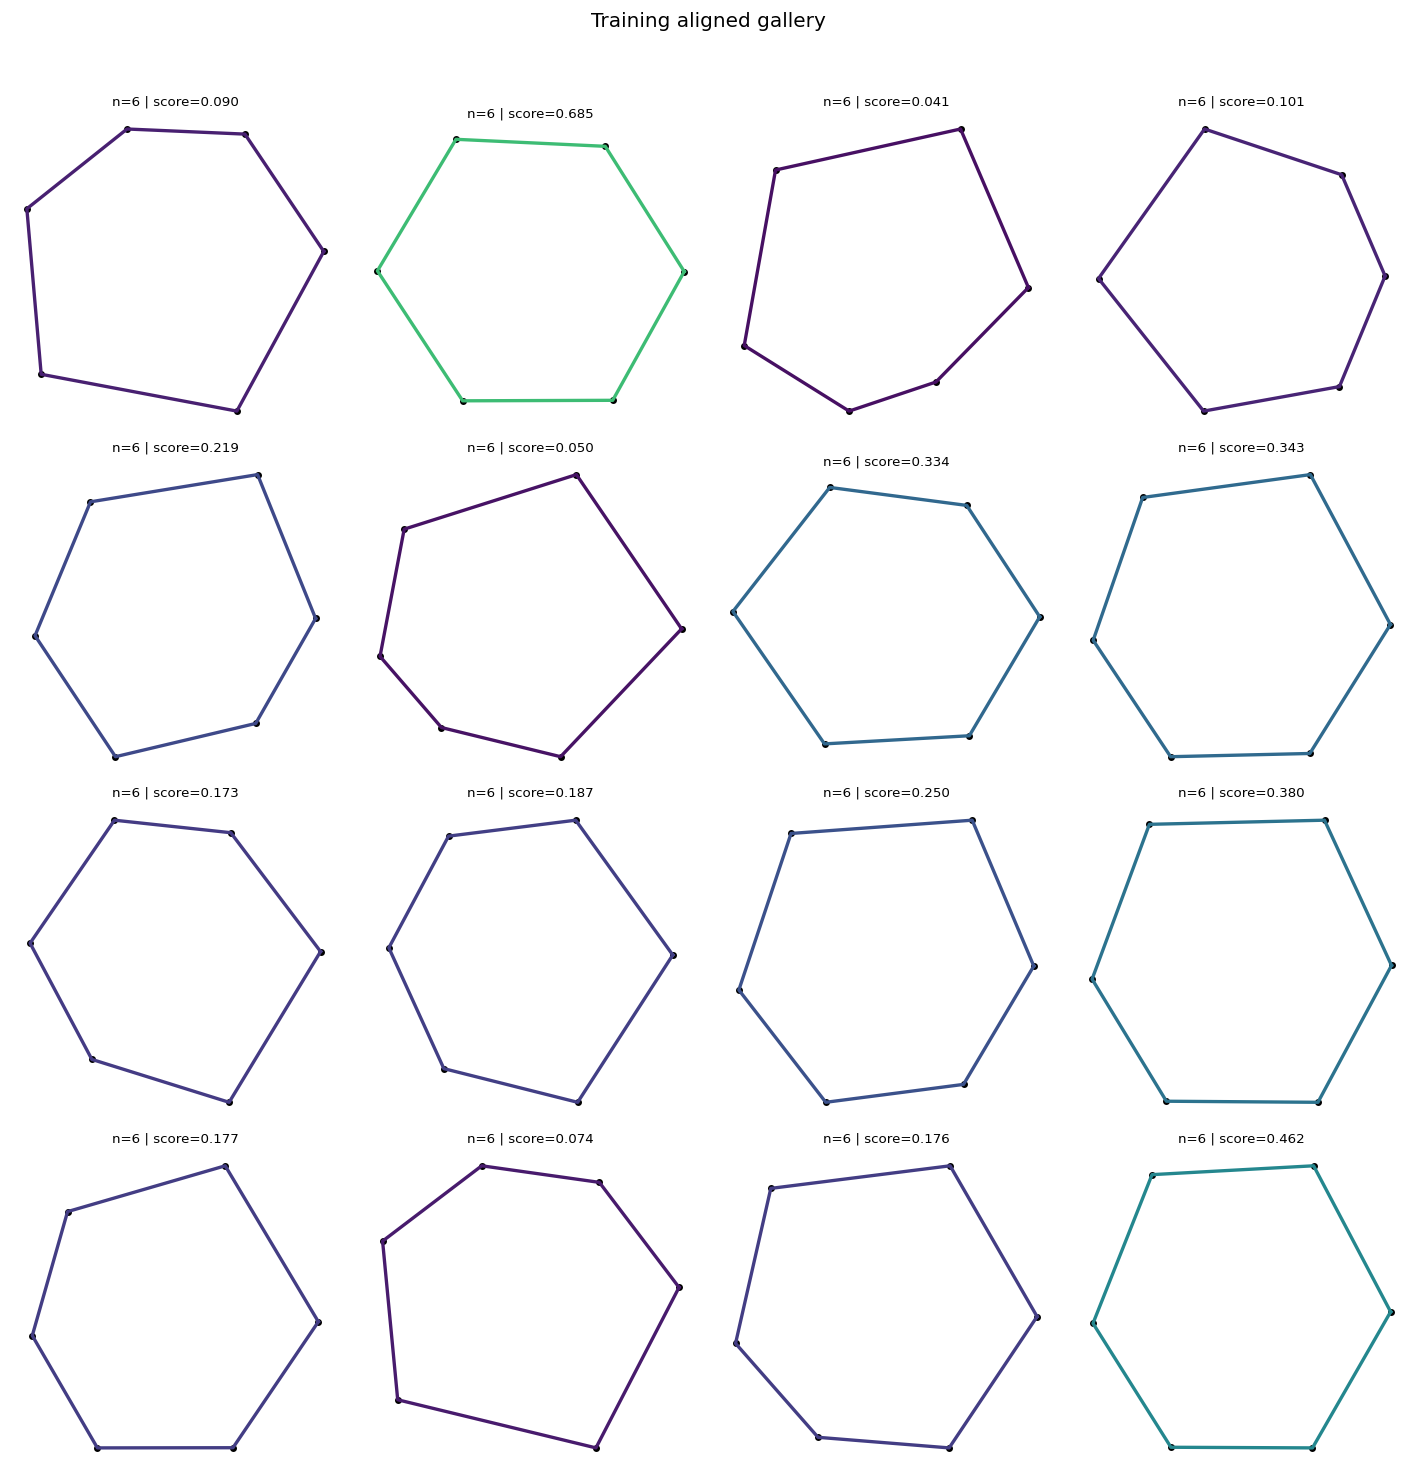

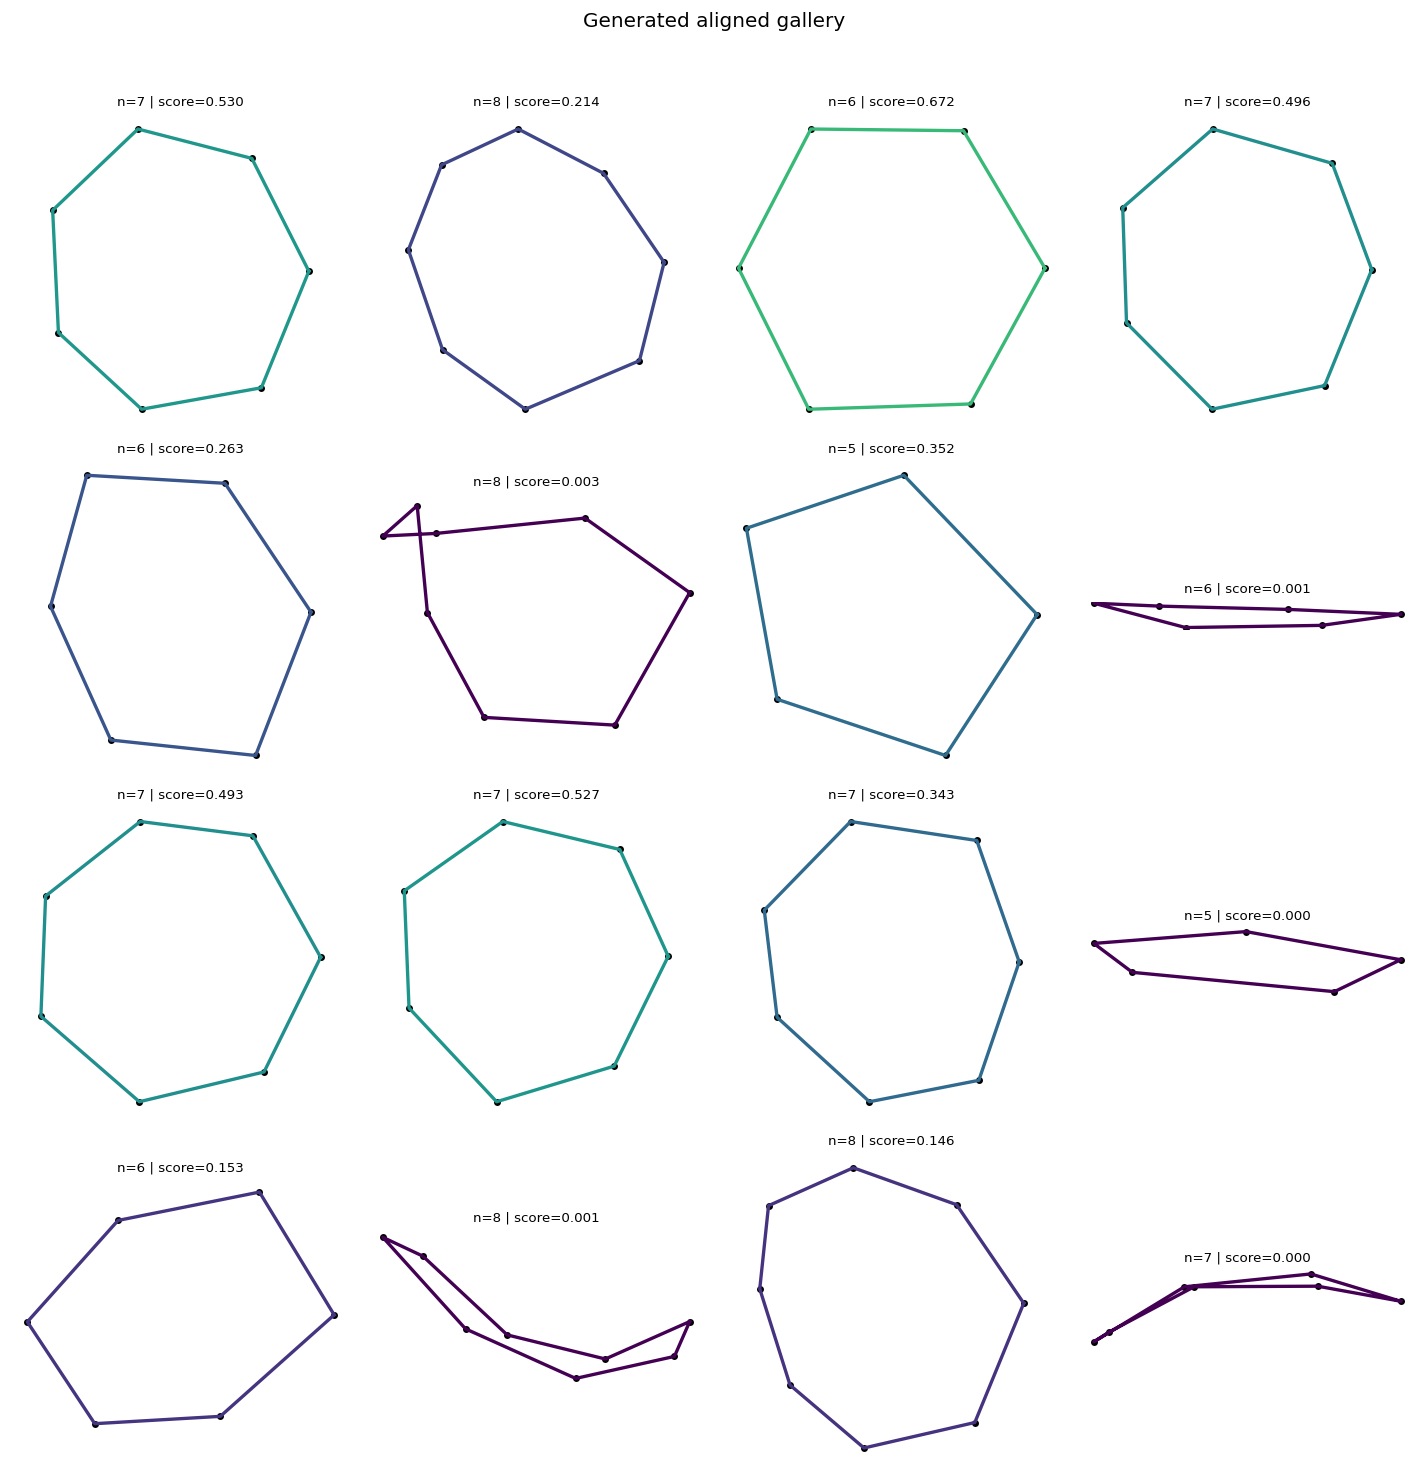

In [28]:
if "score_error" in train_metrics.columns:
    print(
        "training stored-vs-recomputed score max abs error:",
        float(train_metrics["score_error"].abs().max()),
    )

if training["meta"]:
    print("training meta:", training["meta"])
if generated["meta"]:
    print("generated meta:", generated["meta"])

train_scores = train_metrics["score"].to_numpy()
gen_scores = gen_metrics["score"].to_numpy()

# fig = plot_gallery(training["polygons"], train_scores, training["num_vertices"], "Training raw gallery", num=MAX_GALLERY, seed=RANDOM_SEED)
# maybe_save_figure(fig, "training_raw_gallery")
fig = plot_gallery(train_aligned, train_scores, training["num_vertices"], "Training aligned gallery", num=MAX_GALLERY, seed=RANDOM_SEED)
maybe_save_figure(fig, "training_aligned_gallery")
# fig = plot_gallery(generated["polygons"], gen_scores, generated["num_vertices"], "Generated raw gallery", num=MAX_GALLERY, seed=RANDOM_SEED + 1)
# maybe_save_figure(fig, "generated_raw_gallery")
fig = plot_gallery(gen_aligned, gen_scores, generated["num_vertices"], "Generated aligned gallery", num=MAX_GALLERY, seed=RANDOM_SEED + 1)
maybe_save_figure(fig, "generated_aligned_gallery")


## Summary Table

This condenses the two datasets into aggregate statistics.

How to interpret it:
- The first table is overall across every polygon in each dataset.
- If the datasets are mixed-size, that overall table combines shape effects and size-mixture effects.
- The second table is size-conditioned and is more informative when the size histograms differ.
- `mean_score` and `median_score` summarize overall regularity.
- `self_intersection_rate` should ideally stay near zero.
- `mean_edge_cv`, `mean_angle_cv`, and `mean_radius_cv` tell you which geometric component is drifting.
- `mean_area` and `mean_compactness` help separate shape mismatch from score mismatch.

What to expect:
- Fixed-size runs should mostly behave like the original notebook.
- Mixed-size runs often need the size-conditioned table to distinguish a true shape error from a different size prior.


In [29]:
summary_table = (
    combined_metrics.groupby("dataset")
    .agg(
        count=("index", "size"),
        mean_vertices=("n_vertices", "mean"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        self_intersection_rate=("self_intersecting", "mean"),
        mean_edge_cv=("edge_cv", "mean"),
        mean_angle_cv=("angle_cv", "mean"),
        mean_radius_cv=("radius_cv", "mean"),
        mean_area=("area", "mean"),
        mean_compactness=("compactness", "mean"),
    )
    .sort_index()
)

display(summary_table)

size_conditioned_summary = (
    combined_metrics.groupby(["dataset", "n_vertices"])
    .agg(
        count=("index", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        self_intersection_rate=("self_intersecting", "mean"),
        mean_edge_cv=("edge_cv", "mean"),
        mean_angle_cv=("angle_cv", "mean"),
        mean_radius_cv=("radius_cv", "mean"),
        mean_area=("area", "mean"),
        mean_compactness=("compactness", "mean"),
    )
    .sort_index()
)

display(size_conditioned_summary)


,count,mean_vertices,mean_score,median_score,std_score,self_intersection_rate,mean_edge_cv,mean_angle_cv,mean_radius_cv,mean_area,mean_compactness
dataset,,,,,,,,,,,
generated,10000,6.8927,0.3100,0.3404,0.2359,0.0369,0.1294,0.1395,0.1408,2.2939,0.7880
training,10000,6.0000,0.3020,0.2139,0.2692,0.0000,0.1291,0.0832,0.0851,2.5818,0.8911


count  mean_score  std_score  self_intersection_rate  \
dataset   n_vertices                                                         
generated 5            1057      0.3072     0.2585                  0.0114   
          6            1961      0.4203     0.2462                  0.0087   
          7            3980      0.3477     0.2250                  0.0241   
          8            3002      0.1891     0.1752                  0.0813   
training  6           10000      0.3020     0.2692                  0.0000   

                      mean_edge_cv  mean_angle_cv  mean_radius_cv  mean_area  \
dataset   n_vertices                                                           
generated 5                 0.1479         0.1772          0.1484     1.9760   
          6                 0.0897         0.1126          0.1054     2.3309   
          7                 0.1096         0.1235          0.1259     2.3858   
          8                 0.1752         0.1651          0.1810     2.2600   
training  6                 0.1291         0.0832          0.0851     2.5818   

                      mean_compactness  
dataset   n_vertices                    
generated 5                     0.7316  
          6                     0.8177  
          7                     0.8149  
          8                     0.7527  
training  6                     0.8911

## Scalar Metric Distributions

These histograms compare one scalar metric at a time. The dashed line is the mean for each dataset.

How to interpret them:
- Strong overlap is good: it means the generated marginal distribution matches training for that feature.
- A generated curve shifted right means the model is systematically producing larger values for that metric.
- A generated curve shifted left means the model is systematically producing smaller values.
- A much narrower generated curve means the model is under-dispersed.
- A much wider generated curve means the model is injecting too much variability or leaving the training manifold.

Important mixed-size note:
- these histograms are dataset-wide, so if training and generated use different polygon-size mixtures, that difference will also affect the marginals
- use the size-conditioned summary table above to decide whether a mismatch is really a shape problem or mostly a size-distribution problem


saved figure: data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/metric_distributions.png


PosixPath('/Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/metric_distributions.png')

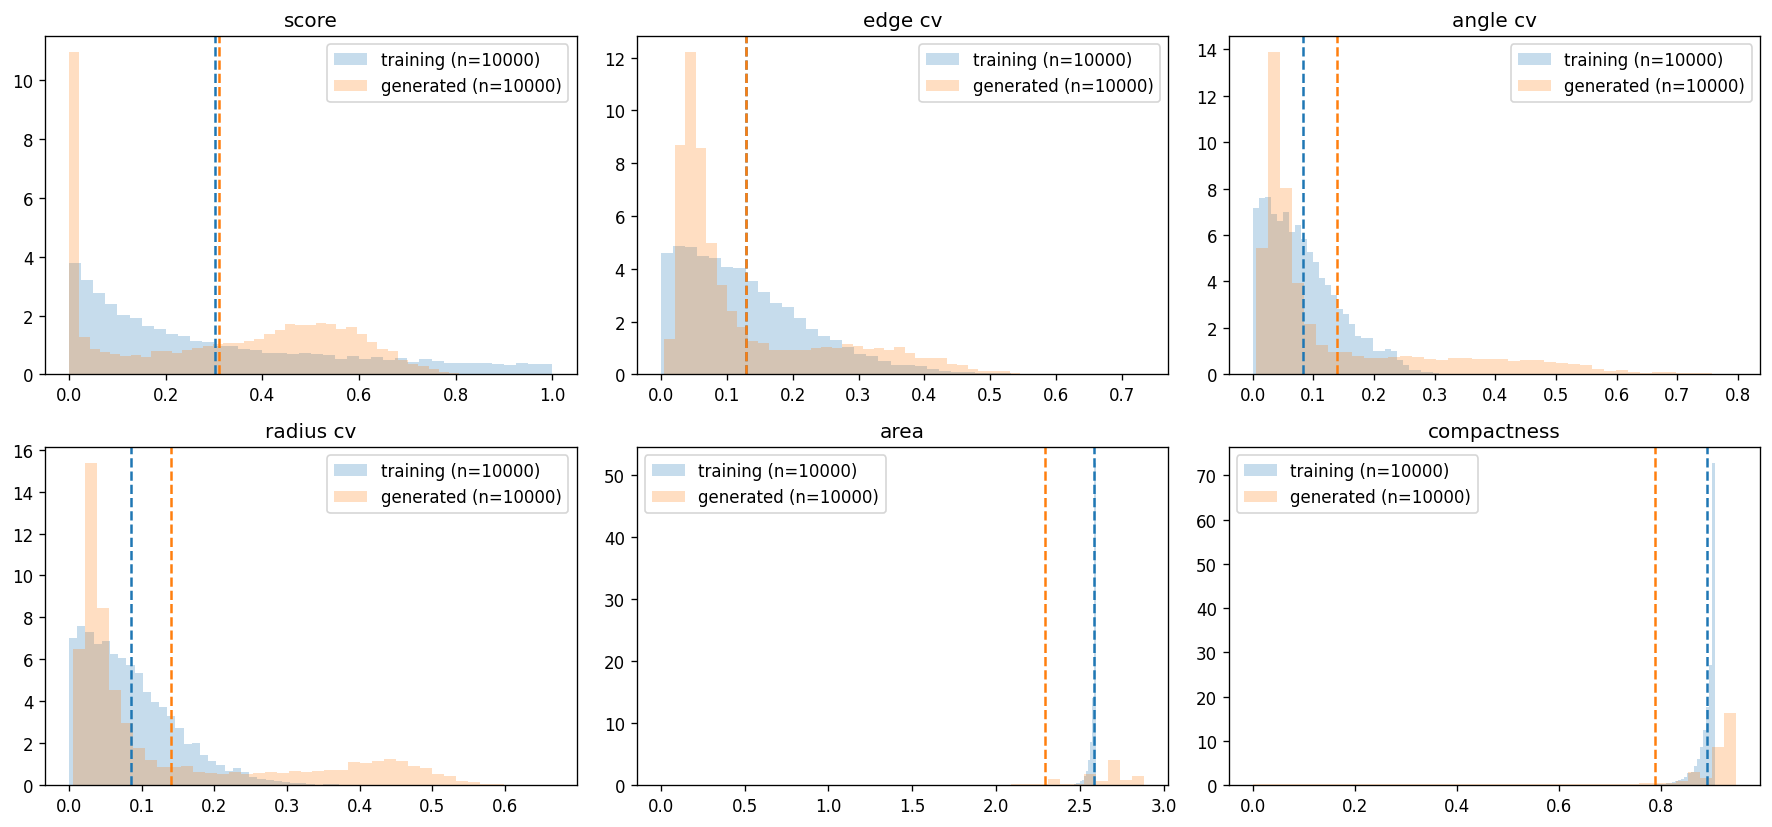

In [30]:
metrics_to_plot = [
    "score",
    "edge_cv",
    "angle_cv",
    "radius_cv",
    "area",
    "compactness",
]

fig = plot_metric_distributions(combined_metrics, metrics_to_plot, bins=40)
maybe_save_figure(fig, "metric_distributions")


## PCA Of Aligned Shapes

This section now runs only on a shared polygon size because PCA needs a consistent flattened coordinate width.

How to interpret it:
- the notebook picks `analysis_n_vertices` automatically from the overlap between training and generated unless you set `ANALYSIS_N_VERTICES` manually
- if the generated cloud overlaps the training cloud, the model is capturing the same broad shape manifold for that polygon size
- if the generated cloud is much tighter, the model is learning the center of the distribution but missing diversity
- if the generated cloud is offset, the model has a systematic bias in shape space for that size

If there is no shared polygon size between the two datasets, this section is skipped.


saved figure: data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/aligned_polygon_pca_n_6.png


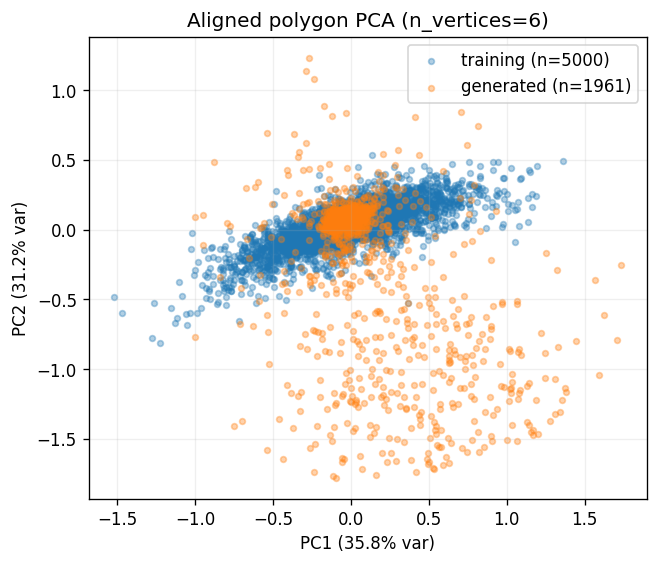

In [31]:
if SELECTED_ANALYSIS_N is None:
    print("No shared n_vertices between training and generated; skipping PCA.")
else:
    train_pca_input = select_polygons_by_size(train_aligned, training["num_vertices"], SELECTED_ANALYSIS_N)
    gen_pca_input = select_polygons_by_size(gen_aligned, generated["num_vertices"], SELECTED_ANALYSIS_N)

    pca_inputs = {
        "training": train_pca_input,
        "generated": gen_pca_input,
    }
    pca_points, explained = fit_pca_2d(pca_inputs, MAX_PCA_SAMPLES_PER_SET, RANDOM_SEED)

    fig, ax = plt.subplots(figsize=(6.0, 5.0))
    colors = {"training": "tab:blue", "generated": "tab:orange"}
    for label, pts in pca_points.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.35, color=colors[label], label=f"{label} (n={len(pts)})")

    ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
    ax.set_title(f"Aligned polygon PCA (n_vertices={SELECTED_ANALYSIS_N})")
    ax.legend()
    ax.grid(alpha=0.2)
    maybe_save_figure(fig, f"aligned_polygon_pca_n_{SELECTED_ANALYSIS_N}")


## Vertex Density And Mean Polygon

Like PCA, this section is only meaningful on a shared polygon size because it stacks aligned vertex positions across many polygons.

How to interpret it:
- if training and generated density lobes line up, the model is putting vertices in the right places on average for that polygon size
- if generated density is much more concentrated than training, the model is producing too little shape diversity
- if generated density is much more diffuse, the model is too noisy or unstable
- if the white mean polygon differs between panels, the model has a systematic average-shape bias

If there is no shared polygon size between the datasets, this section is skipped.


saved figure: data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/vertex_density_n_6.png


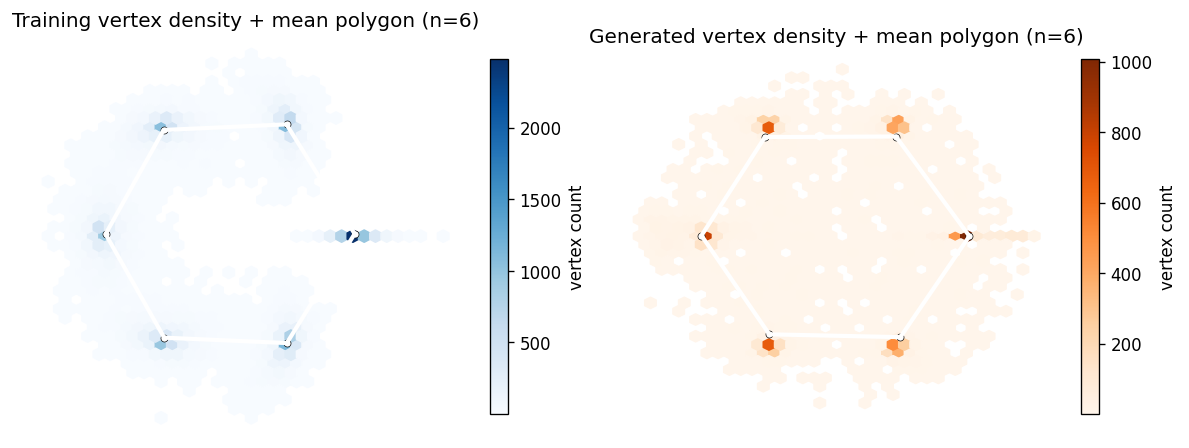

In [32]:
if SELECTED_ANALYSIS_N is None:
    print("No shared n_vertices between training and generated; skipping vertex density plots.")
else:
    train_density = sample_rows(
        select_polygons_by_size(train_aligned, training["num_vertices"], SELECTED_ANALYSIS_N),
        MAX_PCA_SAMPLES_PER_SET,
        RANDOM_SEED,
    )
    gen_density = sample_rows(
        select_polygons_by_size(gen_aligned, generated["num_vertices"], SELECTED_ANALYSIS_N),
        MAX_PCA_SAMPLES_PER_SET,
        RANDOM_SEED + 1,
    )

    fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
    hb_train = plot_vertex_density(axes[0], train_density, f"Training vertex density + mean polygon (n={SELECTED_ANALYSIS_N})", cmap="Blues")
    hb_gen = plot_vertex_density(axes[1], gen_density, f"Generated vertex density + mean polygon (n={SELECTED_ANALYSIS_N})", cmap="Oranges")
    fig.colorbar(hb_train, ax=axes[0], shrink=0.8, label="vertex count")
    fig.colorbar(hb_gen, ax=axes[1], shrink=0.8, label="vertex count")
    fig.tight_layout()
    maybe_save_figure(fig, f"vertex_density_n_{SELECTED_ANALYSIS_N}")


## Training Deform vs Score

This plot only exists for datasets that store the generator's `deform` value. It is mainly a calibration check for the synthetic training distribution.

How to interpret it:
- you should see a clear negative relationship: higher deformation should correspond to lower regularity score
- if the dataset mixes polygon sizes, color can help separate whether the trend differs by `n_vertices`
- if the relationship is weak or upside down, either the stored data is not what you think it is or the score is not capturing the intended notion of regularity
- if the cloud is very narrow in `deform`, the training set may not cover enough variation to teach a broad distribution


saved figure: data/processed/run_0003__polydiff-train-gat-mixed-polygons/sample_0001__polydiff-sample-unguided/media/notebooks/compare_polygon_distributions/training_deform_vs_score.png


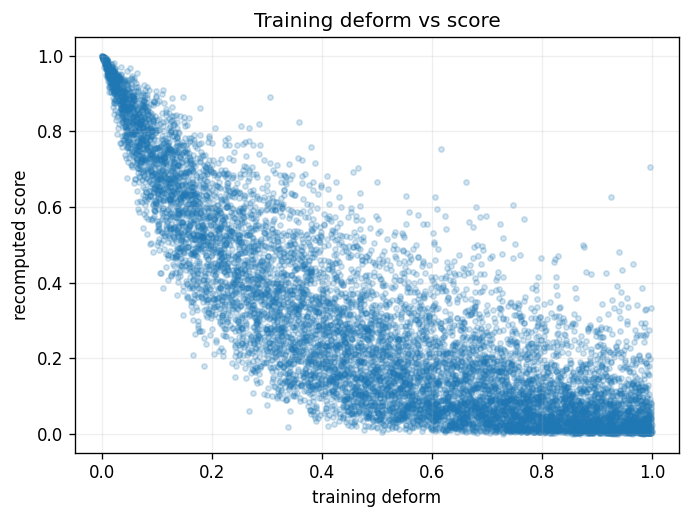

In [33]:
if "deform" in train_metrics.columns:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    unique_sizes = sorted(train_metrics["n_vertices"].unique())
    if len(unique_sizes) == 1:
        ax.scatter(train_metrics["deform"], train_metrics["score"], s=10, alpha=0.2, color="tab:blue")
    else:
        colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(unique_sizes)))
        for color, n in zip(colors, unique_sizes):
            subset = train_metrics.loc[train_metrics["n_vertices"] == n]
            ax.scatter(
                subset["deform"],
                subset["score"],
                s=10,
                alpha=0.18,
                color=color,
                label=f"n={int(n)} (count={len(subset)})",
            )
        ax.legend(fontsize=8)
    ax.set_xlabel("training deform")
    ax.set_ylabel("recomputed score")
    ax.set_title("Training deform vs score")
    ax.grid(alpha=0.2)
    maybe_save_figure(fig, "training_deform_vs_score")
else:
    print("Training file has no deform field.")
